In [2]:
# ==========================================================
# BLOQUE 1: IMPORTACIÓN DE LIBRERÍAS
# ==========================================================

# Manipulación y análisis de datos y grafico
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Division Datos train, test
from sklearn.model_selection import train_test_split

# Implementación del modelo Árbol de Decisión
from sklearn.tree import DecisionTreeClassifier

# Visualización gráfica del árbol entrenado
from sklearn.tree import plot_tree

# Codificación de variables categóricas
from sklearn.preprocessing import LabelEncoder

# Métricas para evaluar el modelo
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print('SUCCESS')

SUCCESS


# Sección nueva

In [11]:
# ==========================================================
# BLOQUE 2: CARGA DEL CONJUNTO DE DATOS
# ==========================================================

# Se carga dataset
df = pd.read_csv("/content/train_u6lujuX_CVtuZ9i.csv")

# Muestra el dataset
df.head()



,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [12]:
# ==========================================================
# BLOQUE 3: EXPLORACIÓN DEL DATASET
# ==========================================================

df.info() #Datos Generales
df.describe()#Datos Epecificos

#nulos=df.isnull().sum()
#print('Cantidad datos Nulos: ', nulos)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [ ]:
# ==========================================================
# BLOQUE 4: Balanceo de Datos
# ==========================================================

# Visualizar la cantidad de valores nulos por columna
print("Valores nulos despues del tratamiento:")
print(df.isnull().sum())

# Se reemplazan los valores nulos por la moda (valor más frecuente)
# Variables Categoricas
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)

# Se reemplazan los valores nulos por la mediana
#Variables numericas
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median(), inplace=True)
df['Credit_History'].fillna(df['Credit_History'].median(), inplace=True)

# Verificacion
print("\nValores nulos después del tratamiento:")
print(df.isnull().sum())



In [ ]:
# Se crea un codificador para transformar texto en valores numéricos
label_encoder = LabelEncoder()

# Se recorren todas las columnas del DataFrame
for columna in df.columns:

    # Si la columna contiene datos de tipo texto (object)
    if df[columna].dtype == 'object':

        # Se reemplazan las categorías por valores numéricos
        df[columna] = label_encoder.fit_transform(df[columna])

# Visualizar las primeras filas para comprobar la transformación
df.head()

In [23]:
# ==========================================================
# BLOQUE 6: SEPARACIÓN DE VARIABLES
# ==========================================================

# Variable objetivo (lo que el modelo debe predecir)
y = df["Loan_Status"]

# Variables predictoras (información utilizada para realizar la predicción)
X = df.drop("Loan_Status", axis=1) # Sustituimos en X

# Mostrar las dimensiones de ambos conjuntos
print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (614, 12)
Dimensiones de y: (614,)


In [24]:
# ==========================================================
# BLOQUE 7: DIVISIÓN DEL CONJUNTO DE DATOS
# ==========================================================

# Se divide el conjunto de datos en entrenamiento (80%)
# y prueba (20%)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Mostrar el tamaño de cada conjunto
print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (491, 12)
Datos de prueba: (123, 12)


In [53]:
# ==========================================================
# BLOQUE 8: CREACIÓN Y ENTRENAMIENTO DEL MODELO
# ==========================================================

# Se crea el modelo de Árbol de Decisión
modelo = DecisionTreeClassifier(
    criterion="gini",
    random_state=42,
    max_depth=5
)

# Se entrena el modelo con los datos de entrenamiento
modelo.fit(X_train, y_train)

print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


In [55]:
# ==========================================================
# BLOQUE 9: PREDICCIÓN DEL MODELO
# ==========================================================

# El modelo realiza predicciones sobre los datos de prueba
y_pred = modelo.predict(X_test)

# Mostrar las primeras 10 predicciones realizadas
print("Primeras 10 predicciones:")
print(y_pred[:10])

Primeras 10 predicciones:
[1 1 1 1 1 1 1 1 1 1]


In [47]:
# ==========================================================
# BLOQUE 10: EVALUACIÓN DEL MODELO
# ==========================================================

# Calcular la exactitud del modelo
accuracy = accuracy_score(y_test, y_pred)

print(f"Exactitud (Accuracy): {accuracy:.2%}")

Exactitud (Accuracy): 74.80%


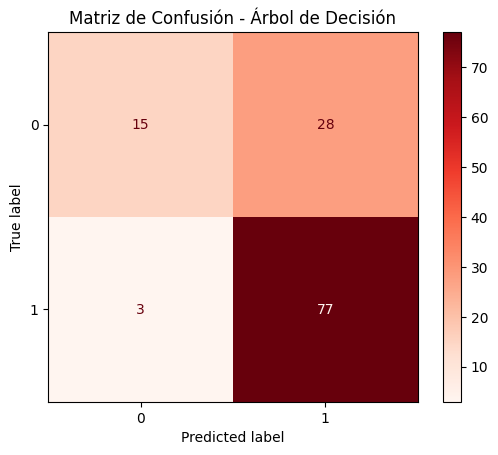

In [50]:
# ==========================================================
# BLOQUE 11: MATRIZ DE CONFUSIÓN
# ==========================================================

# Calcular la matriz de confusión
matriz = confusion_matrix(y_test, y_pred)

# Mostrar la matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=matriz)
disp.plot(cmap="Reds")

# Título del gráfico
plt.title("Matriz de Confusión - Árbol de Decisión")

# Mostrar el gráfico
plt.show()

In [51]:
# ==========================================================
# BLOQUE 12: REPORTE DE CLASIFICACIÓN
# ==========================================================

# Mostrar el reporte de clasificación
print("Reporte de Clasificación:\n")
print(classification_report(y_test, y_pred))

Reporte de Clasificación:

              precision    recall  f1-score   support

           0       0.83      0.35      0.49        43
           1       0.73      0.96      0.83        80

    accuracy                           0.75       123
   macro avg       0.78      0.66      0.66       123
weighted avg       0.77      0.75      0.71       123



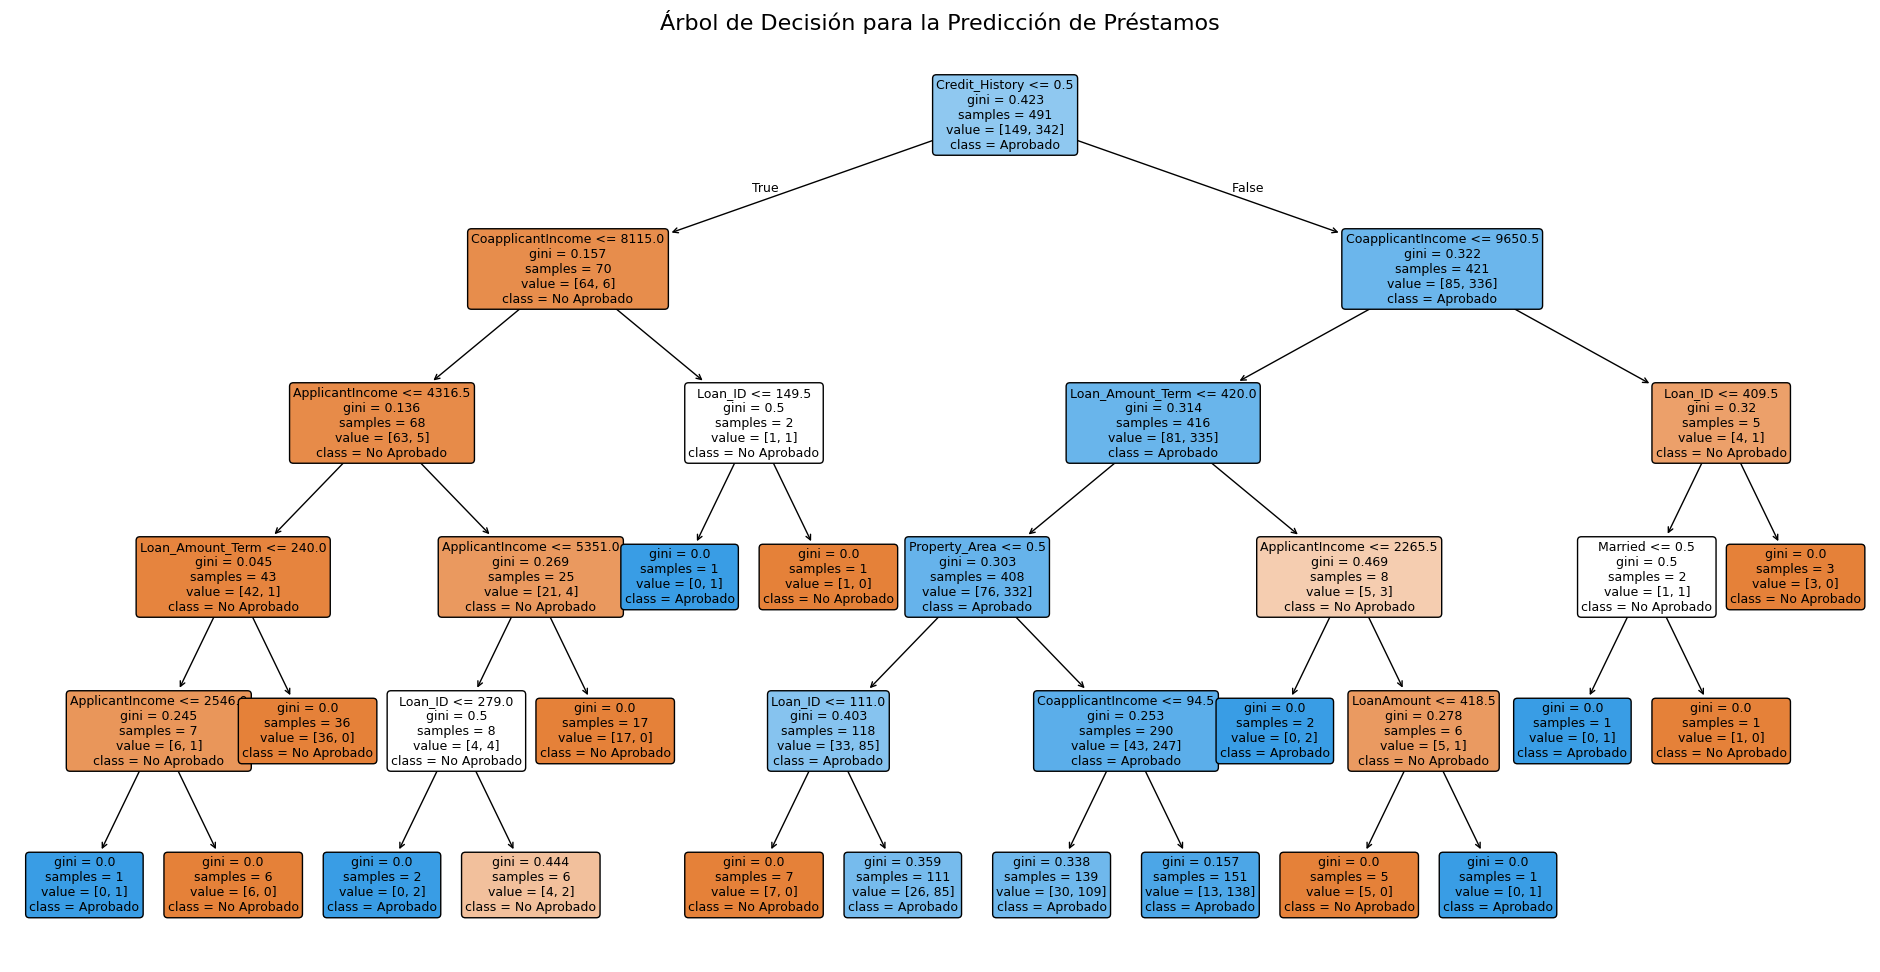

In [56]:
# ==========================================================
# BLOQUE 13: VISUALIZACIÓN DEL ÁRBOL DE DECISIÓN
# ==========================================================

# Ajustar el tamaño de la figura
plt.figure(figsize=(24,12))

# Dibujar el Árbol de Decisión
plot_tree(
    modelo,
    feature_names=X.columns,
    class_names=["No Aprobado", "Aprobado"],
    filled=True,
    rounded=True,
    fontsize=9
)

# Agregar título
plt.title("Árbol de Decisión para la Predicción de Préstamos", fontsize=16)

# Mostrar el gráfico
plt.show()